## Testing quenching.py

## Import and Preprocess

In [1]:
# ================================
# eLoss-only notebook (pub styling)
# ================================
import numpy as np, matplotlib.pyplot as plt, sys
from dataclasses import replace
sys.path.append("../code")

from glauber import SystemSpec, OpticalGlauber
from quenching import QuenchParams, xA0_from_L, qhat_of_x, _l2, dpt_side
from cross_sections import (SigmaPPTable, sigma_avg_in_bin, RpA_vs_centrality, plot_r_vs_y_in_bins, plot_r_vs_pt_in_bins, average_R,
                            L_eff_minbias)
# your Particle and alpha_s providers:
from particle import Particle              # assumes .d2sigma_pp, .mT, .y_max, .xA, .xB implemented
from coupling import alpha_s_provider      # your running/constant αs factory

## Particle Kinematics & Set up

In [2]:
# 1) Systems & Glauber
roots = 8160.0
spec_pA = SystemSpec(system="pA", roots_GeV=roots, A=208, sigma_nn_mb=71.0)
gl      = OpticalGlauber(spec_pA, verbose=False)

In [3]:
# 2) Particles
P_charmonia = Particle(family="charmonia",  state="avg")     # average charmonia (or "Jpsi", etc.)
P_bottomonia = Particle(family="bottomonia", state="avg")     # average bottomonia (or "Upsilon(1S)", etc.)

In [4]:
# coupling constant provider
alpha_run = alpha_s_provider(mode="running", loops=4, method="ode")
alpha_cst = alpha_s_provider(mode="constant", alpha0=0.326)
# alpha_cst = alpha_s_provider(mode="constant", alpha0=0.50)

alpha_s = alpha_cst

# alpha = r"\alpha_s(\Delta p_T)"
# alpha = r"\alpha_s(m_T)"
# alpha = 0.5
alpha = 0.326

In [5]:
## Quenching parameter setting
qp_base   = QuenchParams(
    qhat0=0.075, lp_fm=1.5,
    LA_fm=L_eff_minbias(gl, "pA"), LB_fm=L_eff_minbias(gl, "pA"),
    lambdaQCD=0.308, roots_GeV=roots,
    alpha_of_mu=alpha_s,
    alpha_scale="dpt"  ## mT, or dpt
)

In [6]:
qp_mt  = qp_base.__class__(**{**qp_base.__dict__, "alpha_scale": "mT"})
qp_dpt = qp_base.__class__(**{**qp_base.__dict__, "alpha_scale": "dpt"})

In [7]:
# 2) Kinematics quicklook
pt_grid = np.linspace(0.0, 30.0, 121)
print("mT(J/ψ, 10 GeV) =", P_charmonia.mT(10.0))
print("y_max(5.023 TeV, mT=6 GeV) =", P_charmonia.y_max(5023.0, 6.0))

mT(J/ψ, 10 GeV) = 10.570270810154298
y_max(5.023 TeV, mT=6 GeV) = 6.73002317452199


In [8]:
# 4) Optional σ_pp table (big speedup for scans)
import numpy as np
y_tab  = np.linspace(-5.0, 5.0, 41)
pt_tab = np.linspace(0.0,  25.0, 101)
pp_tab_chi = SigmaPPTable(P_charmonia, roots, y_tab, pt_tab)
pp_tab_bot = SigmaPPTable(P_bottomonia, roots, y_tab, pt_tab)

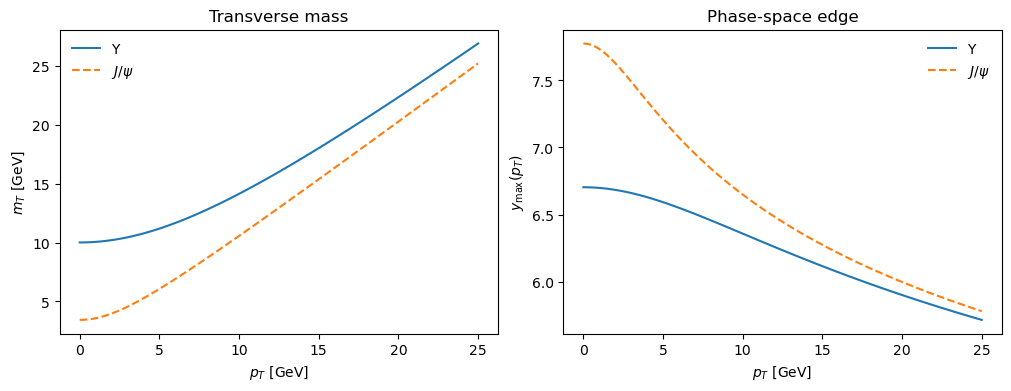

In [9]:
# -------------------------- 1) Kinematics -----------------------------------
fig, ax = plt.subplots(1,2, figsize=(10,3.8), constrained_layout=True)
ax[0].plot(pt_tab, P_bottomonia.mT(pt_tab), label=r"$\Upsilon$")
ax[0].plot(pt_tab, P_charmonia.mT(pt_tab), label=r"$J/\psi$", ls="--")
ax[0].set_xlabel(r"$p_T$ [GeV]"); ax[0].set_ylabel(r"$m_T$ [GeV]")
ax[0].set_title("Transverse mass"); ax[0].legend(frameon=False)

# y_max(pt) for each particle (uses each particle's mass)
ax[1].plot(pt_tab, [P_bottomonia.y_max(roots, P_bottomonia.mT(pt)) for pt in pt_tab], label=r"$\Upsilon$")
ax[1].plot(pt_tab, [P_charmonia.y_max(roots, P_charmonia.mT(pt)) for pt in pt_tab], label=r"$J/\psi$", ls="--")
ax[1].set_xlabel(r"$p_T$ [GeV]"); ax[1].set_ylabel(r"$y_{\max}(p_T)$")
ax[1].set_title("Phase-space edge"); ax[1].legend(frameon=False)
plt.show()

In [10]:
# 5) Define centrality bins (fractions)
cent_edges = (0.0, 0.2, 0.4, 0.6, 0.8, 1.0)   # 0-20-40-60-80-100%

## Glauber Stuffs & $L_{eff}$

In [11]:
# Glauber (pPb @ LHC), then get min-bias L_eff
spec = SystemSpec(system="pA", roots_GeV=8160.0, A=208, sigma_nn_mb=71.0)
gl = OpticalGlauber(spec, verbose=True)
# Min-bias L_eff (optical-style check)
LA_mb = gl.leff_minbias_pA()
print("Min Bias: ", LA_mb)

# For your prints (like the C++ pretty printer)
gl.print_pA_centrality_table([0,100], method="binomial")
gl.print_pA_centrality_table([0,100], method="optical") 

[Glauber] TA(r) LUT: A=208 d=0.549 r≤50 fm, dr=0.02, z≤50 fm
[Glauber] ∫T_A d^2x ≈ 208.483 (target A=208)
[Glauber] Tabulating T_AA(b), T_pA(b)…
[Glauber] σ_tot^AA ≈ 7757.76 mb, σ_tot^pA ≈ 1925.90 mb
Min Bias:  10.414158247314315
--------------------------------------------------------------------------
Centrality  |  N_coll(mean)  |  L_eff [fm]   (method: binomial)
--------------------------------------------------------------------------
   0-100%   |       7.748   |    10.394
--------------------------------------------------------------------------
--------------------------------------------------------------------------
Centrality  |  N_coll(mean)  |  L_eff [fm]   (method: optical)
--------------------------------------------------------------------------
   0-100%   |       7.578   |    10.181
--------------------------------------------------------------------------


In [12]:
# Glauber (pPb @ LHC), then get min-bias L_eff
spec = SystemSpec(system="pA", roots_GeV=8160.0, A=208, sigma_nn_mb=71.0)
gl = OpticalGlauber(spec, verbose=True)

# For your prints (like the C++ pretty printer)
gl.print_pA_centrality_table([0,20,40,60,80,100], method="binomial")
gl.print_pA_centrality_table([0,20,40,60,80,100], method="optical") 

[Glauber] TA(r) LUT: A=208 d=0.549 r≤50 fm, dr=0.02, z≤50 fm
[Glauber] ∫T_A d^2x ≈ 208.483 (target A=208)
[Glauber] Tabulating T_AA(b), T_pA(b)…
[Glauber] σ_tot^AA ≈ 7757.76 mb, σ_tot^pA ≈ 1925.90 mb
--------------------------------------------------------------------------
Centrality  |  N_coll(mean)  |  L_eff [fm]   (method: binomial)
--------------------------------------------------------------------------
   0-20 %   |      14.421   |    14.109
  20-40 %   |      11.504   |     9.455
  40-60 %   |       7.684   |     6.217
  60-80 %   |       3.646   |     3.222
  80-100%   |       1.468   |     1.500
--------------------------------------------------------------------------
--------------------------------------------------------------------------
Centrality  |  N_coll(mean)  |  L_eff [fm]   (method: optical)
--------------------------------------------------------------------------
   0-20 %   |      14.206   |    13.305
  20-40 %   |      11.100   |    10.775
  40-60 %   |     

In [13]:
# Grids
pT = np.linspace(0.0, 30.0, 241)
y  = np.linspace(-5.0, 5.0, 201)

# Centrality-binned L_eff using A&P binomial method (Eq. B.9)
bins = [(0,20),(20,40),(40,60),(60,80),(80,100)]
LA_by_bin = gl.leff_bins_pA(bins, rho0_fm3=0.17, Lp_fm=1.5, method="binomial")

# Optical L_Eff
LA_by_bin_opt = gl.leff_bins_pA(bins, method="optical")

## Transport Parameters

In [14]:
for LA in LA_by_bin_opt.values():
    print(xA0_from_L(LA))

print("-------------")

for LA in LA_by_bin.values():
    print(xA0_from_L(LA))

0.0079058942361563
0.009761736691539357
0.013744846929504732
0.022632468776218873
0.04304220178075266
-------------
0.007455119724571966
0.011125194310946466
0.01691895830720605
0.032643566441426186
0.07012330504619758


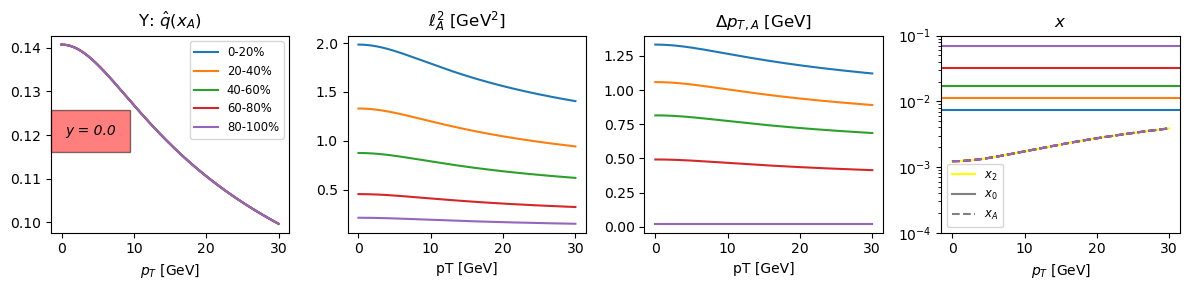

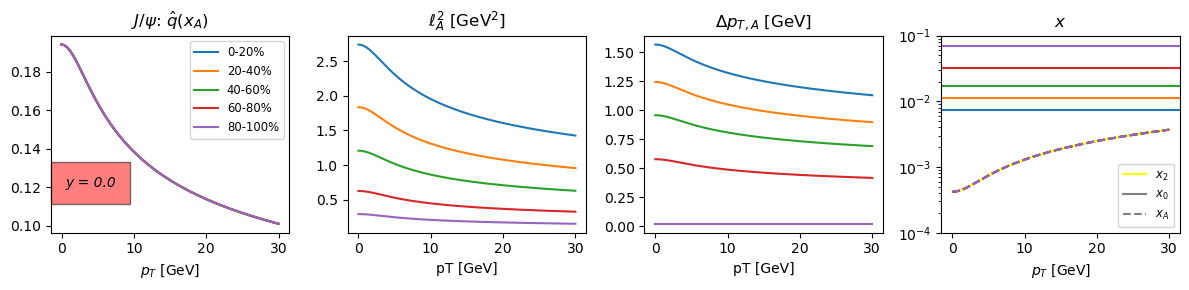

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D # Import this to create custom legend handles

y0 = 0.0
for P, label in [(P_bottomonia, r"$\Upsilon$"), (P_charmonia, r"$J/\psi$")]:
    
    # --- Create 4 subplots ---
    fig, (ax1, ax2, ax3, ax4) = plt.subplots(1, 4, figsize=(12, 3))

    # --- Calculate and plot x2 (which is LA-independent) ---
    x2 = P.x2(y=y0, pT_GeV=pT, roots_GeV=roots)
    # --- CHANGE 1: Add zorder=1 (background) ---
    ax4.plot(pT, x2, color='yellow', linestyle='-', label=r'$x_2$', zorder=1) 

    # --- Iterate over the dictionary's items (key, value) ---
    for bin_label, LA in LA_by_bin.items():
        
        # Calculate x0A and the final xA
        x0A = xA0_from_L(LA)
        xA = np.minimum(x2, x0A)
        
        # Calculate other quantities
        l2A = _l2(qp_base, xA, LA)
        dptA = [dpt_side(qp_base, xx, LA) for xx in xA]

        # Use the 'bin_label' (e.g., '0-20%') for the legend
        legend_label = bin_label

        # Plot on the first 3 axes (these are correct)
        ax1.plot(pT, qhat_of_x(xA, qp_base.qhat0), label=legend_label)
        ax2.plot(pT, l2A, label=legend_label)
        ax3.plot(pT, dptA, label=legend_label)
        
        # Get the color
        line_color = ax1.get_lines()[-1].get_color()
        
        # --- CHANGE 2: Add zorder=2 (foreground) to xA ---
        # This will draw the dashed xA line ON TOP of the other lines
        ax4.plot(pT, xA, linestyle='--', color=line_color, zorder=2)
        
        # --- CHANGE 3: Add zorder=1 (background) to x0 ---
        ax4.axhline(x0A, linestyle='-', color=line_color, zorder=1)

    # --- After the inner loop, set titles, labels, and legends ---
    
    # Set titles and x-labels
    ax1.set_title(label + r": $\hat q(x_A)$")
    ax1.set_xlabel(r"$p_T$ [GeV]")
    ax1.text(0.5, 0.12, f'y = {y0}', style='italic', bbox={'facecolor': 'red', 'alpha': 0.5, 'pad': 10})
    
    ax2.set_title(r"$\ell_A^2$ [GeV$^2$]")
    ax2.set_xlabel("pT [GeV]")
    
    ax3.set_title(r"$\Delta p_{T,A}$ [GeV]")
    ax3.set_xlabel("pT [GeV]")
    
    # Set title and labels for the new 4th plot
    ax4.set_xlabel(r"$p_T$ [GeV]")
    ax4.set_title(r"$x$")
    ax4.set_ylim(1e-4,1e-1)
    ax4.set_yscale("log") # keep the log scale
    
    # --- CHANGE 4: Consolidate centrality legend ---
    # Put a 2-column legend on ax1 and remove the others
    ax1.legend(ncol=1, fontsize='small')
    # ax2.legend() # REMOVED
    # ax3.legend() # REMOVED
    
    # --- FIX 4: Create a custom legend for ax4 ---
    # (This was already correct)
    legend_elements = [
        Line2D([0], [0], color='yellow', linestyle='-', label=r'$x_2$'),
        Line2D([0], [0], color='gray', linestyle='-', label=r'$x_0$'),
        Line2D([0], [0], color='gray', linestyle='--', label=r'$x_A$')
    ]
    ax4.legend(handles=legend_elements, fontsize='small')

    plt.tight_layout()
    plt.show()


## 🎯 Transition Points for $\Upsilon$ (pT=5.0 GeV) 🎯
--------------------------------------------------
Bin Label  | LA       | x0A        | y_transition   
--------------------------------------------------
0-20%      | 14.11    | 7.4551e-03 | -1.693         
20-40%     | 9.45     | 1.1125e-02 | -2.093         
40-60%     | 6.22     | 1.6919e-02 | -2.512         
60-80%     | 3.22     | 3.2644e-02 | -3.170         
80-100%    | 1.50     | 7.0123e-02 | -3.934         
--------------------------------------------------


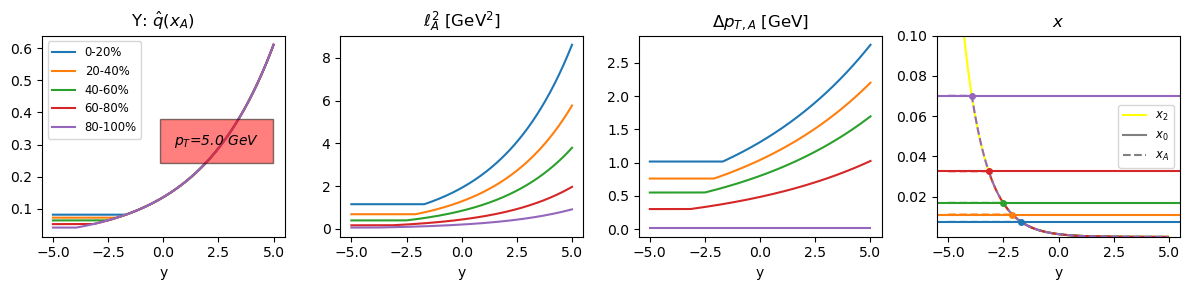


## 🎯 Transition Points for $J/\psi$ (pT=5.0 GeV) 🎯
--------------------------------------------------
Bin Label  | LA       | x0A        | y_transition   
--------------------------------------------------
0-20%      | 14.11    | 7.4551e-03 | -2.306         
20-40%     | 9.45     | 1.1125e-02 | -2.707         
40-60%     | 6.22     | 1.6919e-02 | -3.126         
60-80%     | 3.22     | 3.2644e-02 | -3.783         
80-100%    | 1.50     | 7.0123e-02 | -4.548         
--------------------------------------------------


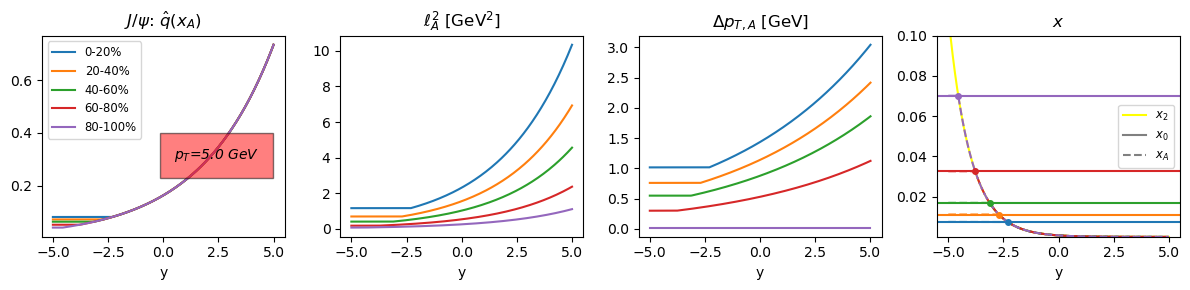

In [16]:
import numpy as np
# ... (rest of the imports)

def _as_array(vals):  # tiny helper that tolerates scalar-returning methods
    return np.asarray(list(vals), dtype=float)

def make_y_panels_for(P, label, pT_fix, roots, y_grid, LA_by_bin, qp_base):
    """Same 4 panels but scanned over y at fixed pT."""
    fig, (ax1, ax2, ax3, ax4) = plt.subplots(1, 4, figsize=(12, 3))
    # x2(y, pT_fix) is LA-independent
    x2 = _as_array(P.x2(y=y_grid, pT_GeV=pT_fix, roots_GeV=roots))
    ax4.plot(y_grid, x2, color='yellow', linestyle='-', label=r'$x_2$', zorder=1)
    
    transition_results = []
    
    for bin_label, LA in LA_by_bin.items():
        x0A = xA0_from_L(LA)
        xA = np.minimum(x2, x0A)
        
        # --- FIXED LOGIC: Find where the sign of (x2 - x0A) changes ---
        # 1. Calculate the difference: x2 is an array, x0A is a scalar
        diff = x2 - x0A
        
        # 2. Find where the sign changes (i.e., when x2 crosses x0A)
        # np.sign(diff) gives -1, 0, or 1. np.diff finds where it changes.
        # The crossing happens where the product of two adjacent sign values is -1.
        sign_change_indices = np.where(np.sign(diff[:-1]) * np.sign(diff[1:]) < 0)[0]
        
        if len(sign_change_indices) > 0:
            # The crossing is between index i and i+1. We take the index i.
            idx = sign_change_indices[0] 
            
            # Use linear interpolation to estimate the exact crossing point
            y1, y2 = y_grid[idx], y_grid[idx + 1]
            x1, x2_val = x2[idx], x2[idx + 1]
            
            # Linear interpolation formula for zero crossing of f(y) = x2(y) - x0A
            # y_cross = y1 + (y2 - y1) * (0 - f(y1)) / (f(y2) - f(y1))
            # f(y) = x2(y) - x0A. f(y1) = x1 - x0A. f(y2) = x2_val - x0A.
            y_cross = y1 + (y2 - y1) * (x0A - x1) / (x2_val - x1)
            
            transition_results.append((bin_label, LA, y_cross, x0A))
        else:
            # If no sign change is found, check if x2 is entirely above or below x0A
            if np.all(x2 < x0A):
                status = "x2 always < x0A (y_trans < y_min)"
            elif np.all(x2 > x0A):
                status = "x2 always > x0A (y_trans > y_max)"
            else:
                status = "Error: No sign change detected"

            transition_results.append((bin_label, LA, status, x0A))
        # --------------------------------------------------------
        
        # transport & broadening along y
        l2A = _l2(qp_base, xA, LA)
        dptA = _as_array(dpt_side(qp_base, x, LA) for x in xA)

        ax1.plot(y_grid, qhat_of_x(xA, qp_base.qhat0), label=bin_label)
        ax2.plot(y_grid, l2A, label=bin_label)
        ax3.plot(y_grid, dptA, label=bin_label)

        col = ax1.get_lines()[-1].get_color()
        ax4.plot(y_grid, xA, linestyle='--', color=col, zorder=2)
        ax4.axhline(x0A, linestyle='-', color=col, zorder=1)
        
        # Optionally, mark the interpolated crossing point on the plot
        if len(sign_change_indices) > 0:
            ax4.plot(y_cross, x0A, 'o', color=col, markersize=4, zorder=3)


    # --- Print the requested results ---
    # (The printing block remains the same, but will now show calculated y values)
    print(f"\n## 🎯 Transition Points for {label} (pT={pT_fix} GeV) 🎯")
    print("-" * 50)
    print(f"{'Bin Label':<10} | {'LA':<8} | {'x0A':<10} | {'y_transition':<15}")
    print("-" * 50)
    for result in transition_results:
        bin_label, LA, y_or_status, x0A = result
        if isinstance(y_or_status, float):
            print(f"{bin_label:<10} | {LA:<8.2f} | {x0A:<10.4e} | {y_or_status:<15.3f}")
        else:
            print(f"{bin_label:<10} | {LA:<8.2f} | {x0A:<10.4e} | {y_or_status:<15}")
    print("-" * 50)
    # -----------------------------------
    
    # ... (rest of the plotting setup)
    ax1.set_title(label + r": $\hat q(x_A)$"); ax1.set_xlabel("y")
    ax1.text(0.5, 0.3, rf'$p_T$={pT_fix} GeV', style='italic', bbox={'facecolor': 'red', 'alpha': 0.5, 'pad': 10})
    ax2.set_title(r"$\ell_A^2$ [GeV$^2$]");    ax2.set_xlabel("y")
    ax3.set_title(r"$\Delta p_{T,A}$ [GeV]");  ax3.set_xlabel("y")
    ax4.set_xlabel("y"); ax4.set_title(r"$x$")
    ax4.set_ylim(1e-4, 1e-1)
    # ax4.set_yscale("log")
    ax1.legend(ncol=1, fontsize='small')
    ax4.legend(handles=[
        Line2D([0],[0], color='yellow', linestyle='-', label=r'$x_2$'),
        Line2D([0],[0], color='gray',  linestyle='-', label=r'$x_0$'),
        Line2D([0],[0], color='gray',  linestyle='--', label=r'$x_A$')
    ], fontsize='small')
    plt.tight_layout(); plt.show()


# ----------------- usage (same spirit as your snippet) -----------------
for P, label in [(P_bottomonia, r"$\Upsilon$"), (P_charmonia, r"$J/\psi$")]:
    make_y_panels_for(P, label, pT_fix=5.0, roots=roots,
                      y_grid=y, LA_by_bin=LA_by_bin, qp_base=qp_base)

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D # Needed for custom legend handles

# --- Assume other necessary functions/objects are defined elsewhere: ---
# P (e.g., P_bottomonia), xA0_from_L, _l2, dpt_side, qhat_of_x
# roots, y_grid (y), LA_by_bin, qp_base
# ----------------------------------------------------------------------

def _as_array(vals): # tiny helper that tolerates scalar-returning methods
    return np.asarray(list(vals), dtype=float)

def make_y_panels_for_X_only(P, label, pT_fix, roots, y_grid, LA_by_bin, qp_base):
    """
    Function to only plot x vs y and show the transition points (x_A = x_0A).
    Ensures proper color cycling for different LA bins.
    """
    # Create a single subplot for the x vs y plot
    fig, ax4 = plt.subplots(1, 1, figsize=(6, 4))
    
    # Initialize the color cycle for the LA bins
    color_cycle = plt.rcParams['axes.prop_cycle'].by_key()['color']
    
    # x2(y, pT_fix) is LA-independent
    x2 = _as_array(P.x2(y=y_grid, pT_GeV=pT_fix, roots_GeV=roots))
    # Plot x2
    ax4.plot(y_grid, x2, color='yellow', linestyle='-', label=r'$x_2$', zorder=1, linewidth=2.5)
    
    transition_results = []
    
    for i, (bin_label, LA) in enumerate(LA_by_bin.items()):
        
        # Select the color for the current bin
        col = color_cycle[i % len(color_cycle)]
        
        # Calculation for xA and x0A
        x0A = xA0_from_L(LA)
        xA = np.minimum(x2, x0A)
        
        # --- Find where the sign of (x2 - x0A) changes (Transition Logic) ---
        diff = x2 - x0A
        sign_change_indices = np.where(np.sign(diff[:-1]) * np.sign(diff[1:]) < 0)[0]
        
        if len(sign_change_indices) > 0:
            idx = sign_change_indices[0]  
            y1, y2 = y_grid[idx], y_grid[idx + 1]
            x1, x2_val = x2[idx], x2[idx + 1]
            
            # Linear interpolation for zero crossing
            y_cross = y1 + (y2 - y1) * (x0A - x1) / (x2_val - x1)
            transition_results.append((bin_label, LA, y_cross, x0A))
        else:
            if np.all(x2 < x0A):
                status = "x2 always < x0A (y_trans < y_min)"
            elif np.all(x2 > x0A):
                status = "x2 always > x0A (y_trans > y_max)"
            else:
                status = "Error: No sign change detected"

            transition_results.append((bin_label, LA, status, x0A))
        # --------------------------------------------------------------------
        
        # Plot xA (dependent on LA)
        ax4.plot(y_grid, xA, linestyle='--', color=col, zorder=2, label=rf'$x_A$ ({bin_label})')
        
        # Plot x0A (horizontal line, dependent on LA)
        ax4.axhline(x0A, linestyle=':', color=col, zorder=1, label=rf'$x_0^A$ ({bin_label})')
        
        # Mark the interpolated crossing point (transition)
        if len(sign_change_indices) > 0:
            ax4.plot(y_cross, x0A, 'o', color=col, markersize=7, markeredgecolor='k', zorder=3)


    # --- Print Transition Points ---
    print(f"\n## 🎯 Transition Points for {label} (pT={pT_fix} GeV) 🎯")
    print("-" * 50)
    print(f"{'Bin Label':<10} | {'LA':<8} | {'x0A':<10} | {'y_transition':<15}")
    print("-" * 50)
    for result in transition_results:
        bin_label, LA, y_or_status, x0A = result
        if isinstance(y_or_status, float):
            print(f"{bin_label:<10} | {LA:<8.2f} | {x0A:<10.4e} | {y_or_status:<15.3f}")
        else:
            print(f"{bin_label:<10} | {LA:<8.2f} | {x0A:<10.4e} | {y_or_status:<15}")
    print("-" * 50)
    # -----------------------------------
    
    # --- Plotting Setup ---
    ax4.set_xlabel("y"); 
    ax4.set_ylabel(r"$x$") 
    ax4.set_title(label + rf": $x(y)$ at $p_T$={pT_fix} GeV")
    ax4.set_ylim(1e-4, 1e-1)
    ax4.set_yscale("log")
    
    # Rebuild the legend to show x2, xA, and x0A for each bin clearly.
    # The automatic legend from the loop (`label` arguments) is better now.
    # We combine the handles from x2 (fixed) and the bin-specific lines.
    handles, labels = ax4.get_legend_handles_labels()
    
    # Group the legend items: x2 first, then bin-specific items
    new_handles = [h for h, l in zip(handles, labels) if l.startswith(r'$x_2$')]
    new_labels = [l for l in labels if l.startswith(r'$x_2$')]
    
    # Add bin-specific items (x_A and x_0A)
    for h, l in zip(handles, labels):
        if not l.startswith(r'$x_2$'):
            new_handles.append(h)
            new_labels.append(l)

    ax4.legend(new_handles, new_labels, fontsize='x-small', loc='upper right', ncol=1)
    
    plt.tight_layout(); 
    plt.show()


## 🎯 Transition Points for $\Upsilon$ (pT=5.0 GeV) 🎯
--------------------------------------------------
Bin Label  | LA       | x0A        | y_transition   
--------------------------------------------------
0-20%      | 14.11    | 7.4551e-03 | -1.693         
20-40%     | 9.45     | 1.1125e-02 | -2.093         
40-60%     | 6.22     | 1.6919e-02 | -2.512         
60-80%     | 3.22     | 3.2644e-02 | -3.170         
80-100%    | 1.50     | 7.0123e-02 | -3.934         
--------------------------------------------------


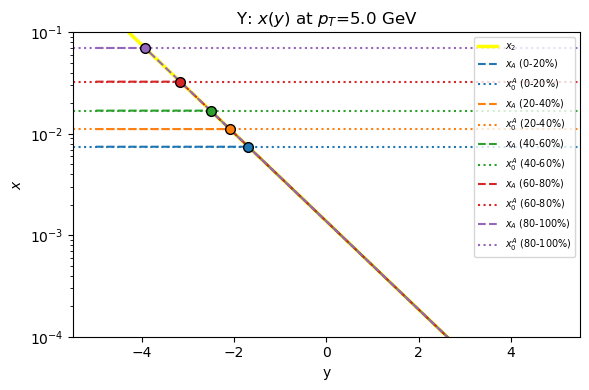


## 🎯 Transition Points for $J/\psi$ (pT=5.0 GeV) 🎯
--------------------------------------------------
Bin Label  | LA       | x0A        | y_transition   
--------------------------------------------------
0-20%      | 14.11    | 7.4551e-03 | -2.306         
20-40%     | 9.45     | 1.1125e-02 | -2.707         
40-60%     | 6.22     | 1.6919e-02 | -3.126         
60-80%     | 3.22     | 3.2644e-02 | -3.783         
80-100%    | 1.50     | 7.0123e-02 | -4.548         
--------------------------------------------------


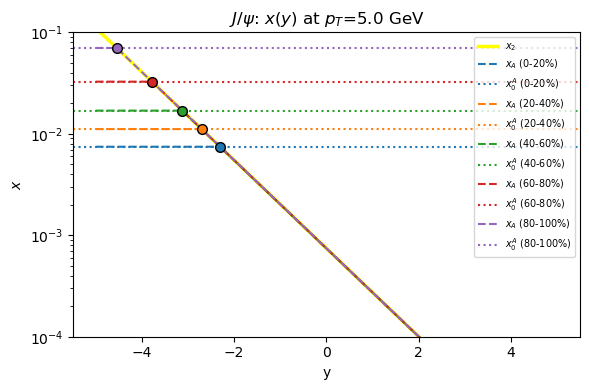

In [18]:
# ----------------- usage (same spirit as your snippet) -----------------
for P, label in [(P_bottomonia, r"$\Upsilon$"), (P_charmonia, r"$J/\psi$")]:
    make_y_panels_for_X_only(P, label, pT_fix=5.0, roots=roots,
                      y_grid=y, LA_by_bin=LA_by_bin, qp_base=qp_base)

 ## Quenching Weights

In [19]:
from quenching import PhatA_vec, _Lambda_p2, _gl_nodes_cached

In [20]:
# --- pick a kinematic point and a centrality (path length) ---
y0, pt0 = 0.5, 5.0
L_A = 2.4         # or any L from your dict
qp   = qp_base.__class__(**{**qp_base.__dict__, "LA_fm": L_A})
# --- kinematics & small-x ---
mT = P_bottomonia.mT(pt0)              # or P_charmonia
ymax = P_bottomonia.y_max(roots, mT)   # = ln(√s/mT)
x2   = P_bottomonia.x2(y=y0, pT_GeV=pt0, roots_GeV=roots)
x0   = xA0_from_L(L_A)
xA   = min(x2, x0)

# --- z-range from Δy_max ---
dy_max = min(np.log(2.0), ymax - y0)
z_max  = np.expm1(dy_max)

# log-density near z→0 is helpful; clamp by module’s Z_FLOOR
Z_MIN = 1e-12
z_grid = np.geomspace(max(Z_MIN, 1e-8), z_max, 200)

# --- P̂_A(z) ---
PA = PhatA_vec(z_grid, y0, pt0, mT, xA, qp)  # shape (len(z_grid),)

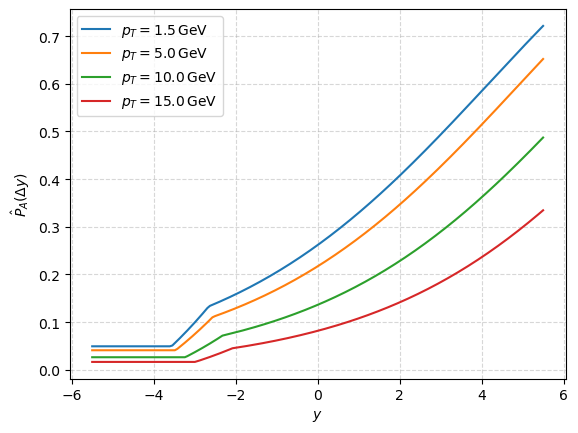

In [21]:
pT_fixes = [1.5, 5.0, 10.0, 15.0]
y_arr = np.linspace(-5.5, 5.5, 181)
dy_star = 0.10  # your chosen Δy

results = {}
for pT_fix in pT_fixes:
    mT_fix = P_bottomonia.mT(pT_fix)
    vals = []
    for yy in y_arr:
        ymax = P_bottomonia.y_max(roots, mT_fix)
        dym  = min(np.log(2.0), ymax - yy)
        if dym <= 1e-12: vals.append(0.0); continue

        x2 = P_bottomonia.x2(y=yy, pT_GeV=pT_fix, roots_GeV=roots)
        xA = min(x2, xA0_from_L(L_A))
        if _l2(qp, xA, qp.LA_fm) <= _Lambda_p2(qp, xA): vals.append(0.0); continue

        z = np.expm1(dy_star)                 # x = ε/E
        Pval = PhatA_vec(np.array([z]), yy, pT_fix, mT_fix, xA, qp)[0]
        vals.append(float(Pval))
    results[pT_fix] = vals

plt.figure()
for pT_fix, vals in results.items():
    plt.plot(y_arr, vals, label=rf'$p_T={pT_fix}\,\mathrm{{GeV}}$')
# plt.yscale('log'); 
plt.xlabel('$y$'); plt.ylabel(r'$\hat P_A(\Delta y)$')
plt.legend(); plt.grid(True, ls='--', alpha=0.5); plt.show()

In [22]:
# --- same setup you already wrote ---
y0, pt0 = 0.5, 5.0
L_A = 5.0
qp   = qp_base.__class__(**{**qp_base.__dict__, "LA_fm": L_A})
mT   = P_bottomonia.mT(pt0)
ymax = P_bottomonia.y_max(roots, mT)
x2   = P_bottomonia.x2(y=y0, pT_GeV=pt0, roots_GeV=roots)
x0   = xA0_from_L(L_A)
xA   = min(x2, x0)

# --- Δy range and *adaptive* Ny (matches pA_cross_section) ---
LOG2 = np.log(2.0)
dym  = min(LOG2, ymax - y0)
if dym <= 1e-12 or _l2(qp, xA, qp.LA_fm) <= _Lambda_p2(qp, xA):
    # then P̂_A contributes 0 in σ_pA
    P_nodes = np.array([0.0]); dy_nodes = np.array([0.0]); dy_w = np.array([0.0])
else:
    Ny0 = 80
    scl = min(1.0, dym/LOG2)
    Ny  = max(16, int(round(Ny0 * scl)))

    # --- the very nodes/weights used by the integrator ---
    dy_nodes, dy_w = _gl_nodes_cached(0.0, dym, Ny)   # Δy-nodes, weights
    z_nodes = np.expm1(dy_nodes)                      # z = e^{Δy} - 1

    # --- THIS is the P̂_A actually used in σ_pA ---
    P_nodes = PhatA_vec(z_nodes, y0, pt0, mT, xA, qp)  # shape (Ny,)

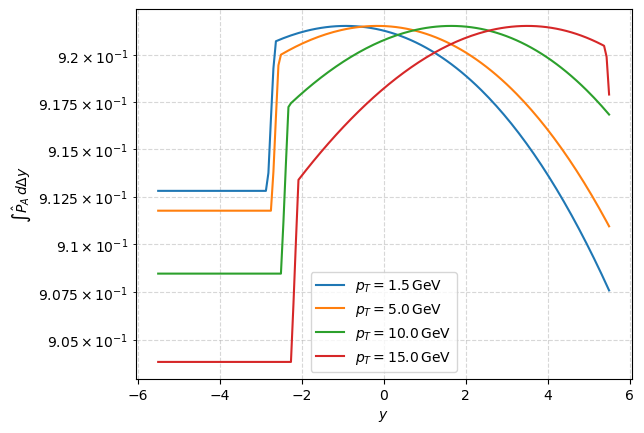

In [23]:
from matplotlib.lines import Line2D

# Assuming P_bottomonia, roots, xA0_from_L, L_A, _l2, qp, _Lambda_p2, _gl_nodes_cached, and PhatA_vec are defined elsewhere

# Define the multiple pT values you want to scan
pT_fixes = [1.5, 5.0, 10.0, 15.0] 
y_arr  = np.linspace(-5.5, 5.5, 181)

# Dictionary to store results: {pT_fix: [list_of_vals]}
results = {}

for pT_fix in pT_fixes:
    vals = []
    
    # Pre-calculate mT since pT_fix is constant in this inner loop
    mT_fix = P_bottomonia.mT(pT_fix) 
    
    for yy in y_arr:
        mT   = mT_fix # Use the pre-calculated value
        ymax = P_bottomonia.y_max(roots, mT)
        dym  = min(np.log(2.0), ymax - yy)
        
        # x2 calculation uses the current yy and the fixed pT_fix
        x2   = P_bottomonia.x2(y=yy, pT_GeV=pT_fix, roots_GeV=roots)
        xA   = min(x2, xA0_from_L(L_A))

        # Check conditions
        if dym <= 1e-12 or _l2(qp, xA, qp.LA_fm) <= _Lambda_p2(qp, xA):
            vals.append(0.0); continue

        # Integration preparation
        Ny0 = 80; scl = min(1.0, dym/np.log(2.0)); Ny = max(16, int(round(Ny0*scl)))
        dy_nodes, dy_w = _gl_nodes_cached(0.0, dym, Ny)
        z_nodes = np.expm1(dy_nodes)
        
        # PhatA_vec uses the current yy and the fixed pT_fix
        P_nodes = PhatA_vec(z_nodes, yy, pT_fix, mT, xA, qp)

        # vals.append(float(np.dot(dy_w, P_nodes)))
        vals.append(float(np.dot(dy_w, P_nodes)))
    
    # Store the results for this pT_fix
    results[pT_fix] = vals

# Plotting the results with legends
plt.figure()
for pT_fix, vals in results.items():
    plt.plot(y_arr, vals, label=rf'$p_T={pT_fix}\, \mathrm{{GeV}}$')

plt.yscale('log')
plt.xlabel('$y$')
plt.ylabel(r'$\int \hat P_A\, d\Delta y$')
plt.legend()
plt.grid(which="both", ls="--", alpha=0.5)
plt.show()

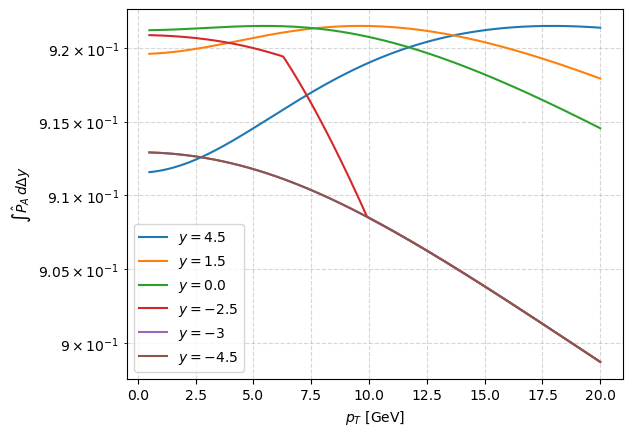

In [24]:
y_fixes = [4.5, 1.5, 0.0, -2.5, -3, -4.5]
pT_arr = np.linspace(0.5, 20.0, 200)

# Dictionary to store results: {y_fix: [list_of_vals]}
results = {}

for y_fix in y_fixes:
    vals = []
    # Calculate once per y_fix for performance if possible, but the original code structure requires loop
    
    for pt in pT_arr:
        mT = P_bottomonia.mT(pt)
        ymax = P_bottomonia.y_max(roots, mT)
        dym = min(np.log(2.0), ymax - y_fix)
        
        # x2 calculation uses the current y_fix
        x2 = P_bottomonia.x2(y=y_fix, pT_GeV=pt, roots_GeV=roots)
        xA = min(x2, xA0_from_L(L_A))

        # Check conditions
        if dym <= 1e-12 or _l2(qp, xA, qp.LA_fm) <= _Lambda_p2(qp, xA):
            vals.append(0.0); continue

        # Integration preparation
        Ny0 = 80; scl = min(1.0, dym/np.log(2.0)); Ny = max(16, int(round(Ny0*scl)))
        dy_nodes, dy_w = _gl_nodes_cached(0.0, dym, Ny)
        z_nodes = np.expm1(dy_nodes)
        
        # PhatA_vec uses the current y_fix
        P_nodes = PhatA_vec(z_nodes, y_fix, pt, mT, xA, qp)

        vals.append(float(np.dot(dy_w, P_nodes)))
    
    # Store the results for this y_fix
    results[y_fix] = vals

# Plotting the results with legends
plt.figure()
for y_fix, vals in results.items():
    plt.plot(pT_arr, vals, label=rf'$y={y_fix}$')

plt.yscale('log')
plt.xlabel(r'$p_T$ [GeV]')
plt.ylabel(r'$\int \hat P_A\, d\Delta y$')
plt.legend()
plt.grid(which="both", ls="--", alpha=0.5)
plt.show()

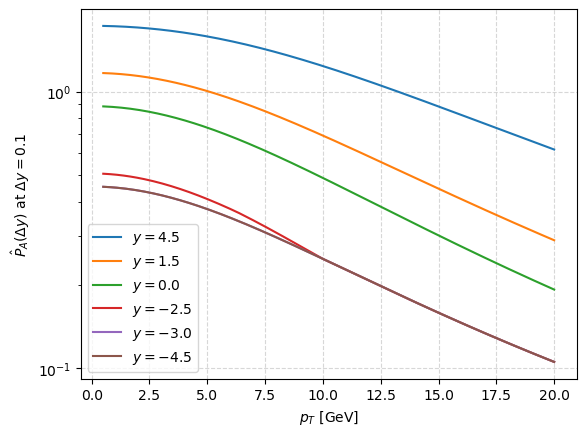

In [25]:
y_fixes = [4.5, 1.5, 0.0, -2.5, -3.0, -4.5]
pT_arr  = np.linspace(0.5, 20.0, 200)
dy_star = 0.10                          # choose a single Δy to evaluate the PDF

results = {}
z_star = np.expm1(dy_star)              # x = ε/E

for y_fix in y_fixes:
    vals = []
    for pt in pT_arr:
        mT   = P_bottomonia.mT(pt)
        ymax = P_bottomonia.y_max(roots, mT)
        dym  = min(np.log(2.0), ymax - y_fix)
        if (dym <= dy_star):            # kinematic cutoff
            vals.append(0.0); continue

        x2 = P_bottomonia.x2(y=y_fix, pT_GeV=pt, roots_GeV=roots)
        xA = min(x2, xA0_from_L(L_A))
        if _l2(qp, xA, qp.LA_fm) <= _Lambda_p2(qp, xA):  # below Λ_p
            vals.append(0.0); continue

        Pval = PhatA_vec(np.array([z_star]), y_fix, pt, mT, xA, qp)[0]
        vals.append(float(Pval))
    results[y_fix] = vals

plt.figure()
for y_fix, vals in results.items():
    plt.plot(pT_arr, vals, label=rf'$y={y_fix}$')
plt.yscale('log'); plt.xlabel(r'$p_T$ [GeV]')
plt.ylabel(fr'$\hat P_A(\Delta y)$ at $\Delta y={dy_star}$')
plt.legend(); plt.grid(True, ls='--', alpha=0.5); plt.show()


In [26]:
# Quenching-weight diagnostics (eta)
from quenching import diagnostics_row
import numpy as np, matplotlib.pyplot as plt
from matplotlib.lines import Line2D

def _as_list(x):
    return x if isinstance(x, (list, tuple, np.ndarray)) else [x]

# --------- P̂A(z_med) vs pT (one OR many fixed y) ----------
def diag_vs_pT_panel(ax, P, y_fix, qpar_base, label, ylim=(0.02,0.25),
                     y_fixes=None, linestyles=("-", "--", ":", "-.")):
    """
    If y_fixes is provided (iterable), plot one curve per y in y_fixes
    using different linestyles; otherwise use y_fix (backwards-compatible).
    Colors = centrality; linestyles = fixed y values.
    """
    y_vals = _as_list(y_fixes if y_fixes is not None else y_fix)
    pt_arr = np.asarray(pT, float)
    style_handles, style_labels = [], []

    # store a consistent color for each centrality (taken from first y)
    color_for_bin = {}

    for j, y0 in enumerate(y_vals):
        ls = linestyles[j % len(linestyles)]
        if y_fixes is not None and j < len(linestyles):
            style_handles.append(Line2D([], [], ls=ls, color='k'))
            style_labels.append(f"y={y0:g}")

        for bin_label, L in LA_by_bin_opt.items():
            qp = qpar_base.__class__(**{**qpar_base.__dict__, "LA_fm": L})
            vals = []
            for pt0 in pt_arr:
                mT = P.mT(pt0); ymx = P.y_max(roots, mT)
                xA = P.xA(y0, pt0, roots, qp.LA_fm)
                row = diagnostics_row(y=y0, pt=pt0, mT=mT, xA=xA, xB=xA, y_max_pt=ymx, qpar=qp)
                vals.append(row["PhA_med"])

            if j == 0:
                line = ax.plot(pt_arr, vals, ls=ls, label=bin_label)[0]
                color_for_bin[bin_label] = line.get_color()
            else:
                ax.plot(pt_arr, vals, ls=ls, color=color_for_bin[bin_label])

    # # axes cosmetics
    # if ylim is None:
    #     ymin, ymax = ax.get_ylim(); pad = 0.05*(ymax - ymin or 1.0)
    #     ax.set_ylim(max(0.0, ymin - pad), ymax + pad)
    # else:
    #     ax.set_ylim(*ylim)
    ax.set_xlim(0, 20)
    ax.set_yscale('log')
    ax.set_xlabel(r"$p_T$ [GeV]")
    ax.set_ylabel(r"$\hat P_A(\epsilon)$")
    ax.set_title(label + (fr" at $y={y_fix}$" if y_fixes is None else ""))

    # legends: main = centralities; style key (if multiple y's)
    leg1 = ax.legend(frameon=False, fontsize='small')
    if y_fixes is not None:
        leg2 = ax.legend(style_handles, style_labels, 
                         frameon=False, fontsize='small', loc="center right")
        ax.add_artist(leg1)

# --------- P̂A(z_med) vs y (one OR many fixed pT) ----------
def diag_vs_y_panel(ax, P, pt_fix, qpar_base, label, ylim=(0.02,0.5),
                    pt_fixes=None, linestyles=("-", "--", ":", "-.")):
    """
    If pt_fixes is provided (iterable), plot one curve per pT in pt_fixes
    using different linestyles; otherwise use pt_fix (backwards-compatible).
    Colors = centrality; linestyles = fixed pT values.
    """
    pt_vals = _as_list(pt_fixes if pt_fixes is not None else pt_fix)
    y_arr = np.asarray(y, float)
    style_handles, style_labels = [], []
    color_for_bin = {}

    for j, pt0 in enumerate(pt_vals):
        ls = linestyles[j % len(linestyles)]
        if pt_fixes is not None and j < len(linestyles):
            style_handles.append(Line2D([], [], ls=ls, color='k'))
            style_labels.append(f"{pt0:g} GeV")

        for bin_label, L in LA_by_bin_opt.items():
            qp = qpar_base.__class__(**{**qpar_base.__dict__, "LA_fm": L})
            mT = P.mT(pt0); ymx = P.y_max(roots, mT)

            vals = []
            for yy in y_arr:
                xA = P.xA(yy, pt0, roots, qp.LA_fm)
                row = diagnostics_row(y=yy, pt=pt0, mT=mT, xA=xA, xB=xA, y_max_pt=ymx, qpar=qp)
                vals.append(row["PhA_med"])

            if j == 0:
                line = ax.plot(y_arr, vals, ls=ls, label=bin_label)[0]
                color_for_bin[bin_label] = line.get_color()
            else:
                ax.plot(y_arr, vals, ls=ls, color=color_for_bin[bin_label])
    plt.text(0.4, 0.02, rf'$\alpha_s = {alpha} $', fontsize=12, color='blue', ha='center', va='bottom')
    # if ylim is None:
    #     ymin, ymax = ax.get_ylim(); pad = 0.05*(ymax - ymin or 1.0)
    #     ax.set_ylim(max(0.0, ymin - pad), ymax + pad)
    # else:
    #     ax.set_ylim(*ylim)
    ax.set_xlim(-5, 5)
    ax.set_yscale('log')
    ax.set_xlabel(r"$y$")
    ax.set_ylabel(r"$\hat P_A(\epsilon)$")
    ax.set_title(label + (fr" at $p_T={pt_fix}$ GeV" if pt_fixes is None else ""))

    leg1 = ax.legend(frameon=False, fontsize='small')
    if pt_fixes is not None:
        leg2 = ax.legend(style_handles, style_labels, 
                         frameon=False, fontsize='small', loc="center left")
        ax.add_artist(leg1)

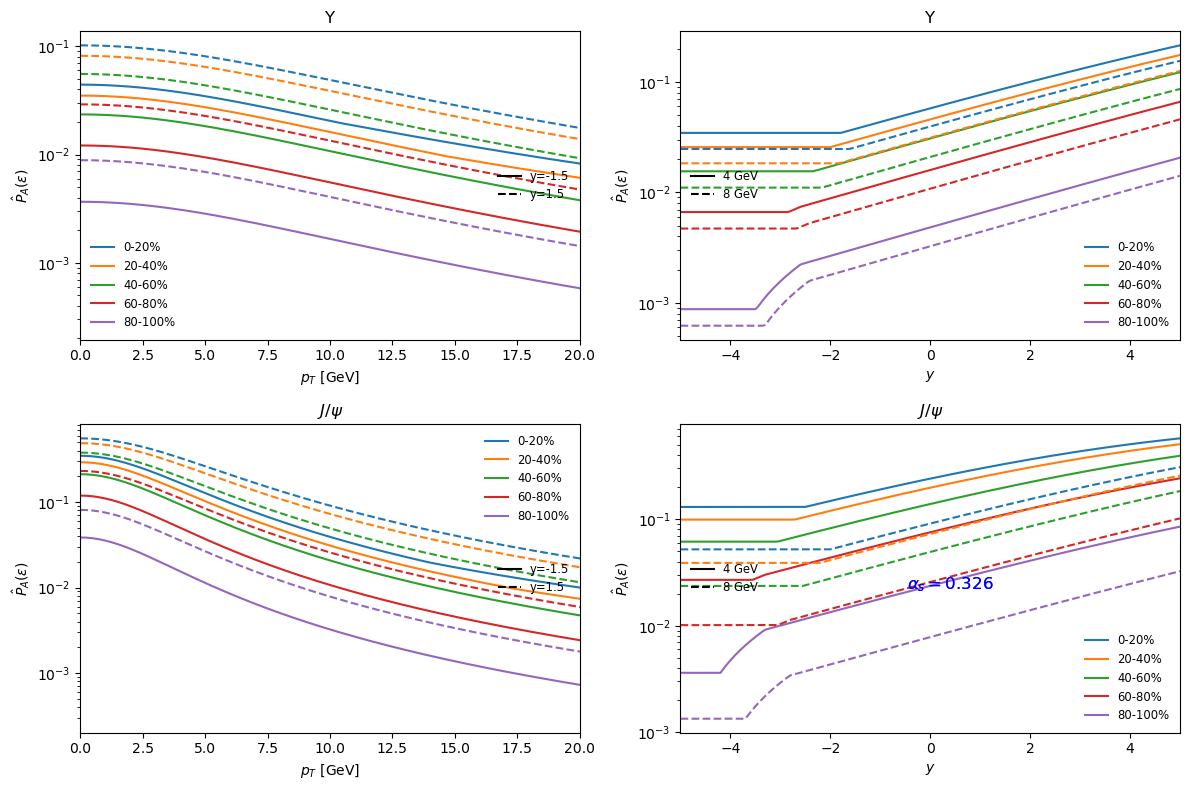

In [27]:
# Create a 2x2 grid of subplots
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(12, 8))

# Top-left: Υ, P̂A vs pT for three y's
diag_vs_pT_panel(axes[0,0], P=P_bottomonia, y_fix=0.5, qpar_base=qp_base,
                 label=r"$\Upsilon$", ylim=(0.0,0.32),
                 y_fixes=[-1.5, 1.5])   # ← solid/dashed/dotted

# Top-right: Υ, P̂A vs y for three pT's
diag_vs_y_panel(axes[0,1], P=P_bottomonia, pt_fix=5.0, qpar_base=qp_base,
                label=r"$\Upsilon$", ylim=(0.0,0.32),
                pt_fixes=[4, 8])

# Bottom row: J/ψ, same idea
diag_vs_pT_panel(axes[1,0], P=P_charmonia, y_fix=0.5, qpar_base=qp_base,
                 label=r"$J/\psi$", ylim=(0.0,0.8),
                 y_fixes=[-1.5, 1.5])

diag_vs_y_panel(axes[1,1], P=P_charmonia, pt_fix=5.0, qpar_base=qp_base,
                label=r"$J/\psi$", ylim=(0.0,0.8),
                pt_fixes=[4, 8])

plt.tight_layout()
plt.show()

## Cross Sections

## Coupling Used

In [28]:
# ---------- tiny helpers (array-safe alpha_s + xA) ----------
alpha_run = alpha_s_provider(mode="running", loops=4, method="ode")

def alpha_apply(mu):
    """Array-safe alpha_s: works for float or np.ndarray."""
    mu_arr = np.atleast_1d(mu).astype(float)
    out = np.empty_like(mu_arr)
    for i, m in enumerate(mu_arr):
        out[i] = alpha_run(float(m))
    return out if np.ndim(mu) else float(out[0])

def xA_of(P, y, pT_arr, roots, LA):
    """x_A(y, pT; LA) = min( x2(y,pT), x0(LA) )."""
    x2 = P.x2(y=y, pT_GeV=pT_arr, roots_GeV=roots)
    x0 = xA0_from_L(LA)
    return np.minimum(x2, x0)

# ---------- compare αs(mT) vs αs(ΔpT) for ALL centrality bins ----------
def plot_alpha_vs_pT_all_bins(P, roots, y_fix=0.5, bins=None, pT_grid=None,
                              show_scales=True, freeze_floor=1.01):
    """
    Top:   αs(mT) (one curve) and αs(ΔpT) (one per centrality bin) vs pT.
    Bottom: the actual scales μ used (mT and ΔpT) vs pT.
    """
    if bins is None:
        bins = list(LA_by_bin_opt.keys())
    if pT_grid is None:
        pT_grid = np.linspace(0.0, 20.0, 200)

    pT_arr = np.asarray(pT_grid, float)
    mT_arr = P.mT(pT_arr)
    # αs at μ = mT (independent of centrality)
    alpha_mT = alpha_apply(mT_arr)
    
    # figure
    import matplotlib.pyplot as plt
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(7, 6), sharex=True)

    # plot αs(mT) once
    l_main, = ax1.plot(pT_arr, alpha_mT, lw=2.5, color="k", label=r"$\alpha_s(\mu{=}m_T)$")

    # per-bin αs(ΔpT)
    for bl in bins:
        LA = LA_by_bin_opt[bl]
        xA = xA_of(P, y_fix, pT_arr, roots, LA)
        dpt = np.array([dpt_side(QuenchParams(LA_fm=LA), float(xx), LA) for xx in xA])
        mu_dpt = np.maximum(dpt, freeze_floor * QuenchParams().lambdaQCD)
        alpha_dpt = alpha_apply(mu_dpt)
        ax1.plot(pT_arr, alpha_dpt, lw=1.8, ls="--", label=f"{bl}: " + r"$\alpha_s(\Delta p_T)$")

        if show_scales:
            ax2.plot(pT_arr, mu_dpt, lw=1.4, ls="--", label=f"{bl}: " + r"$\mu=\Delta p_T$")

    # scales panel
    if show_scales:
        ax2.plot(pT_arr, mT_arr, lw=1.8, color="k", label=r"$\mu=m_T$")
        ax2.set_ylabel(r"$\mu$ [GeV]")
        ax2.legend(frameon=False, ncol=2, fontsize="small")
    plt.text(19, 15, rf'${P.tag} $', fontsize=12, color='blue', ha='center', va='bottom')
    
    ax1.set_ylabel(r"$\alpha_s(\mu)$")
    ax1.legend(frameon=False, ncol=2, fontsize="small")
    ax2.set_xlabel(r"$p_T$ [GeV]")
    plt.tight_layout()
    plt.show()


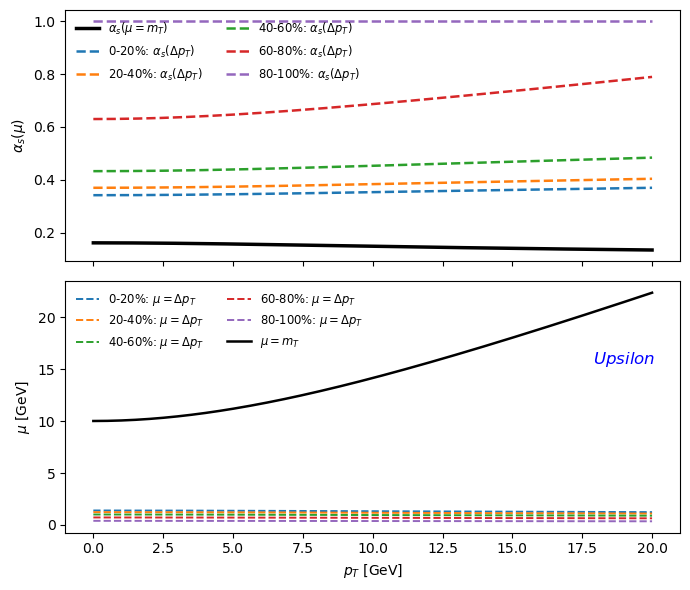

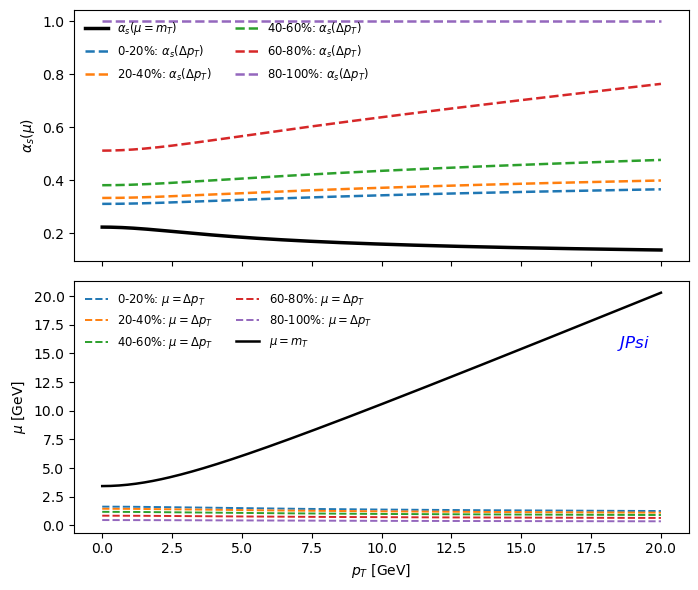

In [29]:
# Pick species & energy
plot_alpha_vs_pT_all_bins(P_bottomonia, roots=8160.0, y_fix=0.5)
plot_alpha_vs_pT_all_bins(P_charmonia,  roots=8160.0, y_fix=0.5)

In [30]:
# === αs(mT) vs αs(ΔpT): pT-scan and y-scan (final minimal add-on) ==============
import numpy as np, matplotlib.pyplot as plt
from quenching import QuenchParams, dpt_side, xA0_from_L

# Running coupling (same normalization as your C++)
alpha_run = alpha_s_provider(mode="running", loops=4, method="ode", freeze=True, alpha_max=0.9)

# Vectorized safe wrapper (alpha_run expects scalars)
_vec_alpha = np.vectorize(lambda mu: float(alpha_run(float(mu))))

# One base QuenchParams — we’ll clone to vary LA_fm only
qp_base = QuenchParams(alpha_of_mu=alpha_run, alpha_scale="mT", LA_fm=10.11, lp_fm=1.5, lambdaQCD=0.308)

def _xA_array(P, y_fix, pT_arr, roots, LA):
    """x_A(y,pT; L_A) = min(x_2, x_0(L_A))"""
    x0 = float(xA0_from_L(LA))
    x2 = np.array([P.x2(y_fix, pt, roots) for pt in pT_arr], dtype=float)
    return np.minimum(x2, x0)

def _xA_array_vs_y(P, y_arr, pT_fix, roots, LA):
    """x_A(y,pT_fix; L_A) = min(x_2, x_0(L_A)) as function of y"""
    x0 = float(xA0_from_L(LA))
    x2 = np.array([P.x2(yy, pT_fix, roots) for yy in y_arr], dtype=float)
    return np.minimum(x2, x0)

def _dpt_array(qp_like, xA_arr, LA):
    """ΔpT for an array of xA values (uses ℓ_A^2-ℓ_p^2 > 0 guard inside dpt_side)."""
    return np.array([dpt_side(qp_like, x, LA) for x in xA_arr], dtype=float)

# ------------------------------- Figure 1: scan in pT (fixed y) ----------------
def plot_alpha_vs_pT(P, roots, y_fix=0.5, bins=("0-20%","20-40%","40-60%","60-80%","80-100%")):
    pt_arr = np.asarray(pT, float)
    mT_arr = P.mT(pt_arr)

    # αs(μ=mT) (same for all bins)
    alpha_mT = _vec_alpha(np.maximum(mT_arr, 1.01*qp_base.lambdaQCD))

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(7.0, 7.5), sharex=True)
    # αs(mT) once
    ax1.plot(pt_arr, alpha_mT, color='0.35', lw=2.0, label=r"$\alpha_s(\mu{=}m_T)$")
    # μ=mT once
    ax2.plot(pt_arr, mT_arr,  color='0.35', lw=1.8, label=r"$\mu=m_T$")

    # Per-bin ΔpT curves
    for bin_label in bins:
        if bin_label not in LA_by_bin_opt: 
            continue
        LA = float(LA_by_bin_opt[bin_label])
        qp_bin = QuenchParams(**{**qp_base.__dict__, "LA_fm": LA})

        xA_arr  = _xA_array(P, y_fix, pt_arr, roots, LA)
        dpt_arr = _dpt_array(qp_bin, xA_arr, LA)
        mu_dpt  = np.maximum(dpt_arr, 1.01*qp_base.lambdaQCD)
        alpha_dpt = _vec_alpha(mu_dpt)

        line, = ax1.plot(pt_arr, alpha_dpt, ls="--", lw=2.0,
                         label=fr"$\alpha_s(\Delta p_T)$ {bin_label}")
        ax2.plot(pt_arr, mu_dpt, ls="--", lw=1.8, color=line.get_color(),
                 label=fr"$\Delta p_T$ {bin_label} (L={LA:.2f} fm)")

    ax1.set_ylabel(r"$\alpha_s(\mu)$"); ax1.set_ylim(0.0, 1.0)
    ax1.legend(frameon=False, ncol=2)

    ax2.set_xlabel(r"$p_T$ [GeV]")
    ax2.set_ylabel(r"$\mu$ [GeV]")
    ax2.legend(frameon=False, ncol=2)
    plt.tight_layout()
    plt.show()

# ------------------------------- Figure 2: scan in y (fixed pT) ----------------
def plot_alpha_vs_y(P, roots, pT_fix=5.0, bins=("0-20%","20-40%","40-60%","60-80%","80-100%")):
    y_arr = np.asarray(y, float)
    mT_fix = float(P.mT(pT_fix))
    alpha_mT_const = float(_vec_alpha(np.maximum(mT_fix, 1.01*qp_base.lambdaQCD))[()])  # scalar

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(7.0, 7.5), sharex=True)

    # αs(mT) is y-independent (mT depends only on pT), plot as a flat line
    ax1.plot(y_arr, np.full_like(y_arr, alpha_mT_const), color='0.35', lw=2.0,
             label=fr"$\alpha_s(m_T)$ ($p_T={pT_fix}$)")
    # μ=mT flat line (for reference)
    ax2.plot(y_arr, np.full_like(y_arr, mT_fix),  color='0.35', lw=1.8,
             label=fr"$m_T$ (const)")

    # Per-bin ΔpT(y) curves (xA depends on y)
    for bin_label in bins:
        if bin_label not in LA_by_bin_opt:
            continue
        LA = float(LA_by_bin_opt[bin_label])
        qp_bin = QuenchParams(**{**qp_base.__dict__, "LA_fm": LA})

        xA_arr  = _xA_array_vs_y(P, y_arr, pT_fix, roots, LA)
        dpt_arr = _dpt_array(qp_bin, xA_arr, LA)
        mu_dpt  = np.maximum(dpt_arr, 1.01*qp_base.lambdaQCD)
        alpha_dpt = _vec_alpha(mu_dpt)

        line, = ax1.plot(y_arr, alpha_dpt, ls="--", lw=2.0,
                         label=fr"$\alpha_s(\Delta p_T)$ {bin_label}")
        ax2.plot(y_arr, mu_dpt, ls="--", lw=1.8, color=line.get_color(),
                 label=fr"$\Delta p_T$ {bin_label} (L={LA:.2f} fm)")

    ax1.set_ylabel(r"$\alpha_s(\mu)$"); ax1.set_ylim(0.0, 1.0)
    ax1.legend(frameon=False, ncol=2)

    ax2.set_xlabel(r"$y$")
    ax2.set_ylabel(r"$\mu$ [GeV]")
    ax2.legend(frameon=False, ncol=2)
    plt.tight_layout()
    plt.show()

/home/sawin/anaconda3/envs/research/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:2625: RuntimeWarning: overflow encountered in <lambda> (vectorized)
  outputs = ufunc(*args, out=...)


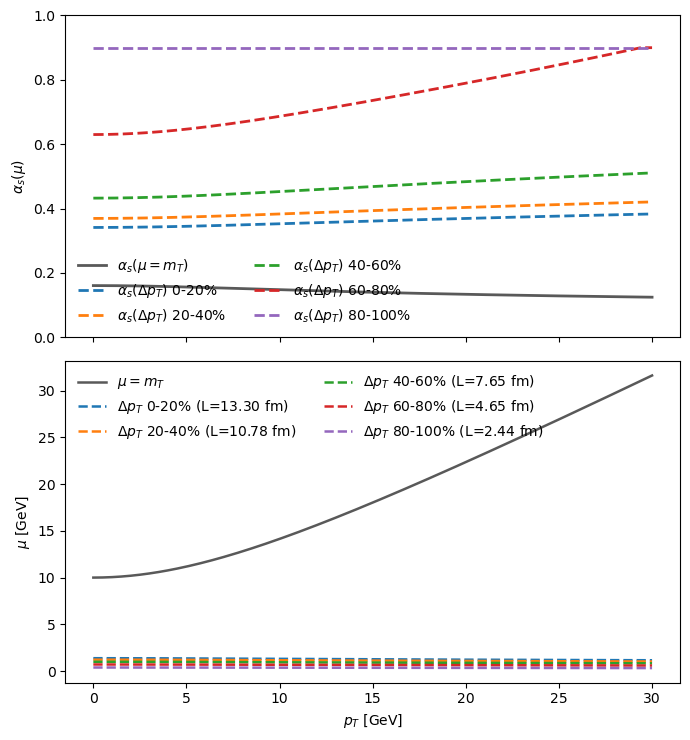

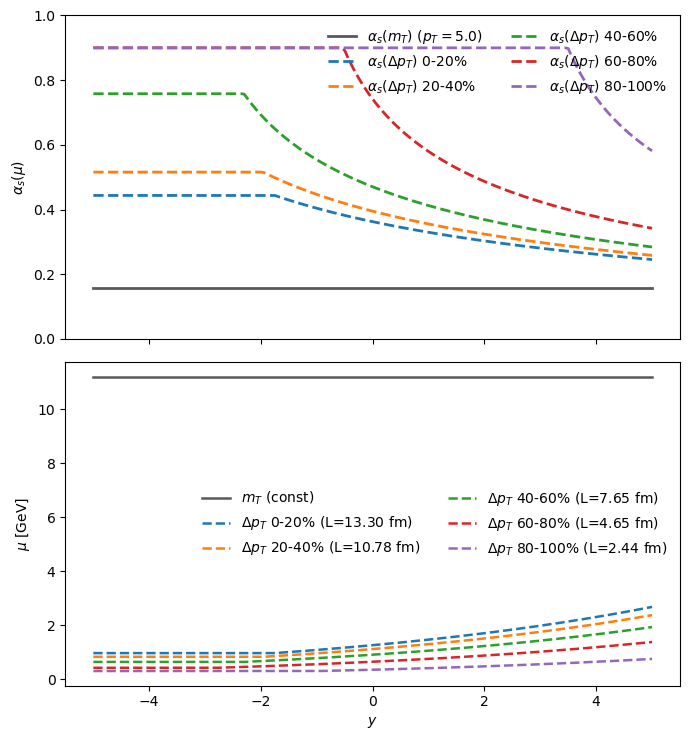

In [31]:
# -------------------------- Example calls (match your flow) -------------------
# Bottomonia: compare across centralities
plot_alpha_vs_pT(P_bottomonia, roots=8160.0, y_fix=0.5)
plot_alpha_vs_y (P_bottomonia, roots=8160.0, pT_fix=5.0)

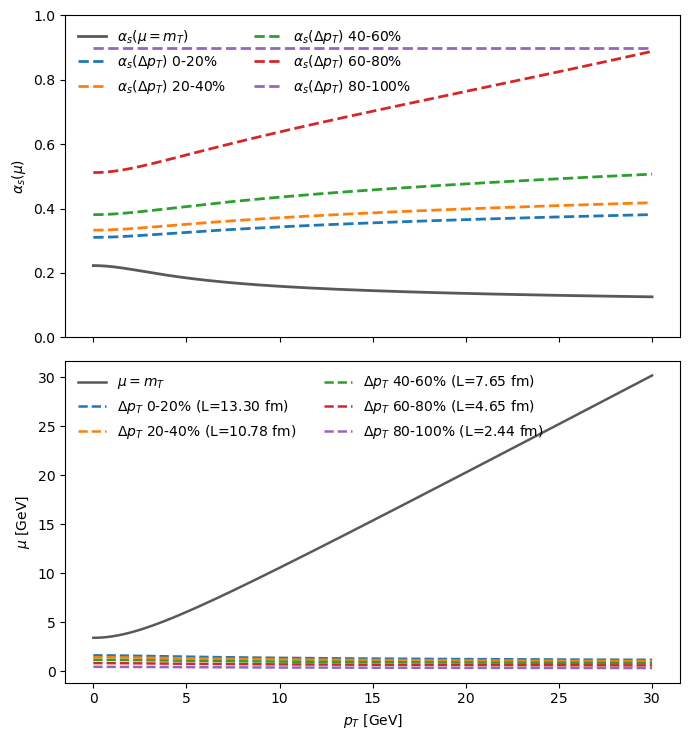

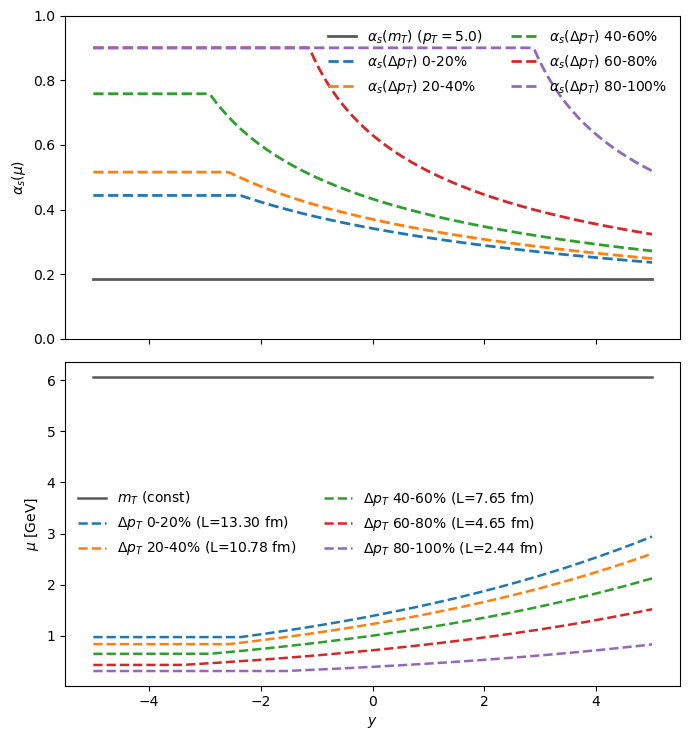

In [32]:
# Charmonia: same
plot_alpha_vs_pT(P_charmonia,  roots=8160.0, y_fix=0.5)
plot_alpha_vs_y (P_charmonia,  roots=8160.0, pT_fix=5.0)